## GeoPandas with Date Picker

#### This program reads in a SnowmanData csv file and a shapefile (for the map) to display where and when a snowman could be built.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import geopandas as gpd

import ipywidgets as widgets
from IPython.display import display, clear_output

### VARIABLES

In [84]:
SHP_FILE = 's_18mr25.shp'
SNOWMAN_FILE = 'SnowmanData_2020s.csv'
RADIUS_IN_KILOMETERS = 50
FIG_SIZE = (40,40)

#### A technical note about the maps and the region markers -

##### I did not want to use markers of undefined size. I wanted to be precise and create circles that would have a specified radius around each weather station. To do this on a plane would not be difficult, but doing this on a sphere is actually pretty complicated!  Using the buffer function by itself would result in skewed circles, and they would be more or less skewed depending on the location of the circles.  In order to correct for this skew, we have to incorporate the Coordinate Reference System (CRS) functionality in GeoPandas, which utilizes European Petroleum Survey Group (EPSG) codes. To fully understand how all of this works is beyond the scope of this presentation, but these functions and codes make it so that when I want to plot circles of specified radius (in geographic distance) around a given point, those circles are displayed accurately and not skewed.

### Set up the map

In [21]:
# create the geodataframe
usa_gdf = gpd.read_file(SHP_FILE)

# remove areas that are not part of the lower 48 states
usa_gdf = usa_gdf.drop([2, 10, 36, 43, 51, 53, 54, 55, 56, 58])

# crs = Coordinate Reference System
# epsg (European Petroleum Survey Group) is a standard for referencing coordinate systems
# epsg:3395 is the Mercator projection
# this is the projection used by Google Maps
usa_gdf = usa_gdf.to_crs('epsg:3395')

### Set up the GeoDataFrame

In [22]:
snowman_df = pd.read_csv(SNOWMAN_FILE)
# epsg:4326 is the WGS 84 coordinate system used by GPS
# this is the coordinate system used by most mapping software
snowman_gdf = gpd.GeoDataFrame(snowman_df, geometry=gpd.points_from_xy(snowman_df.LONGITUDE, snowman_df.LATITUDE), crs='epsg:4326')

# convert the coordinate system to epsg:3395 to be consistent with the usa_gdf
snowman_gdf = snowman_gdf.to_crs('epsg:3395')

# create a buffer around the snowman points to designate the region of interest
# the buffer is in meters, so 50000 is 50 km
snowman_gdf['geometry'] = snowman_gdf.buffer(RADIUS_IN_KILOMETERS * 1000)

### FUNCTIONS

In [85]:
# Function to plot data for a selected date
def plot_date(selected_date):
    fig, ax = plt.subplots(figsize=FIG_SIZE)
    ax.set_facecolor('black')
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    
    # create the plot title
    if selected_date > '2024-12-31':
        title = 'Where Can I Build a Snowman? ' + selected_date + ' (Predicted)'
    else:
        title = 'Where Can I Build a Snowman? ' + selected_date + ' (Actual)'
    ax.set_title(title, fontdict={'fontsize': '64'})

    # filter to the date selected by the user
    tmp_gdf = snowman_gdf[snowman_gdf['DATE'] == selected_date]

    # create the legend
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Snowman Possible', markerfacecolor='white', markersize=20),
                       Line2D([0], [0], marker='o', color='w', label='Snowman Not Possible', markerfacecolor='red', markersize=20),
                       Line2D([0], [0], marker='o', color='w', label='Data Not Available', markerfacecolor='black', markersize=20)]
    legend = ax.legend(handles=legend_elements, loc='lower right', fontsize='32',
                       title = 'Each circle is ' + str(RADIUS_IN_KILOMETERS) + ' km in radius centered on a weather station')
    plt.setp(legend.get_title(), fontsize='20')

    # create and plot the two sets of snowman data
    snowman_no_gdf = tmp_gdf[snowman_gdf['SNOWMAN'] == 0]
    snowman_yes_gdf = tmp_gdf[snowman_gdf['SNOWMAN'] == 1]
    snowman_no_gdf.plot(ax=ax, color='red')
    snowman_yes_gdf.plot(ax=ax, color='white')
    usa_gdf.plot(ax=ax, color='None', edgecolor='lightgreen') 

In [86]:
# Function to update plot on date picker change
def on_date_change(change):
    clear_output()
    plot_date(change['new'].strftime('%Y-%m-%d'))

### RUN

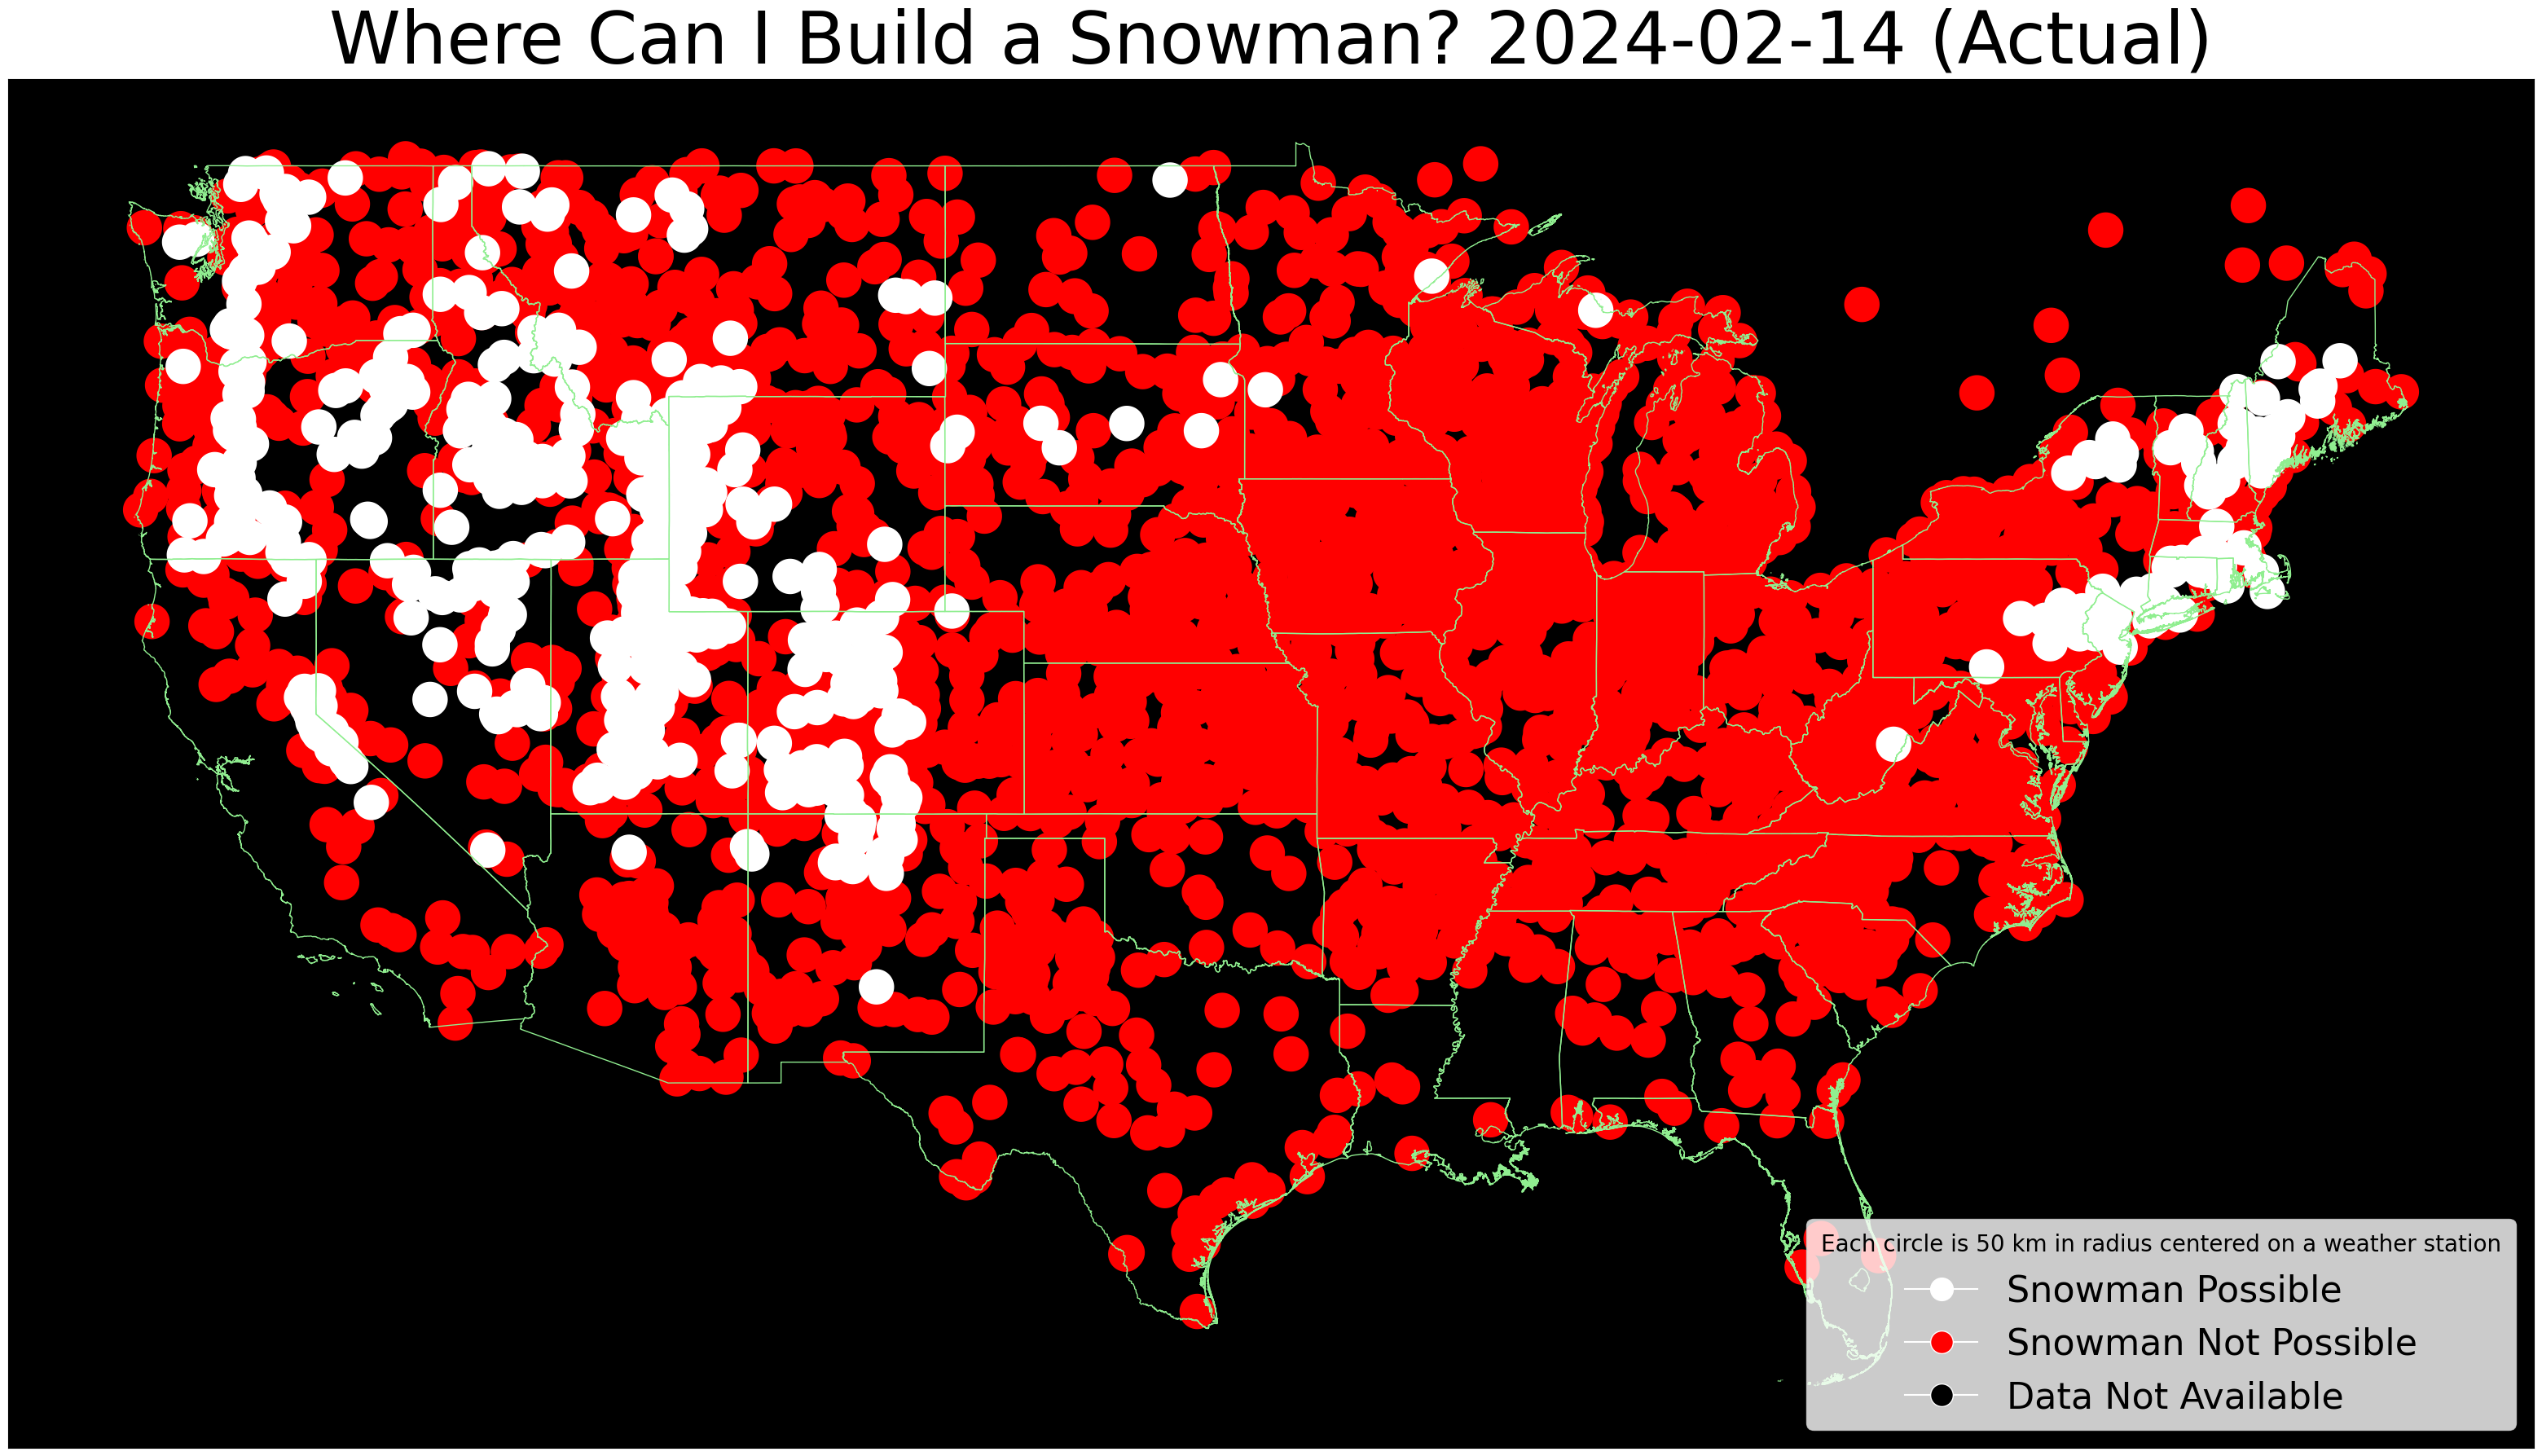

In [87]:
# Create a date selection widget
date_picker = widgets.DatePicker(
    description='Select a Date',
    disabled=False
)
# Watch for changes in the date selection widget
date_picker.observe(on_date_change, names='value')

In [88]:
# Display the date selection widget
display(widgets.HTML("<h3>Choose a date to see where you could build a snowman!</h3>"))
display(date_picker)

HTML(value='<h3>Choose a date to see where you could build a snowman!</h3>')

DatePicker(value=None, description='Select a Date', step=1)